<a href="https://colab.research.google.com/github/Thamilselvan1699/Recruitment/blob/main/hiring_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CandidateID    10 non-null     object        
 1   JobRole        10 non-null     object        
 2   AppliedDate    10 non-null     datetime64[ns]
 3   InterviewDate  10 non-null     datetime64[ns]
 4   OfferDate      10 non-null     datetime64[ns]
 5   Status         10 non-null     object        
 6   Source         10 non-null     object        
 7   Skills         10 non-null     object        
dtypes: datetime64[ns](3), object(5)
memory usage: 772.0+ bytes


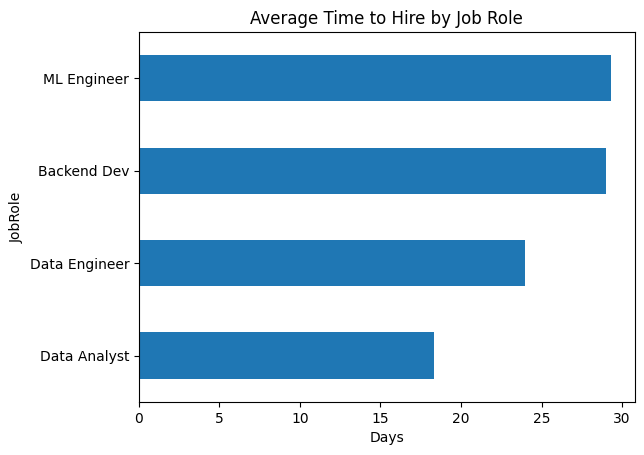

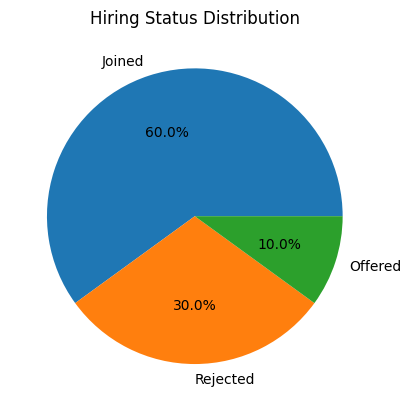

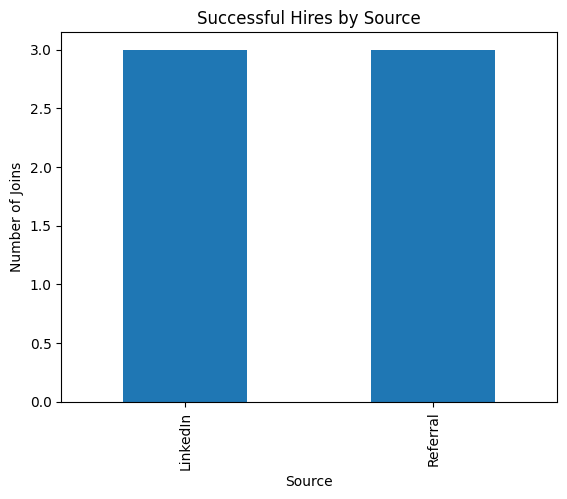

,count
Skills,
Python,7
SQL,5
Power BI,1
Spark,1
AWS,1
TensorFlow,1
ML,1
Excel,1
Tableau,1


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel("/content/job_applicant_dataset.xlsx")

df.head()
df.info()
df['Status'].value_counts()
date_cols = ['AppliedDate', 'InterviewDate', 'OfferDate']

for col in date_cols:
    df[col] = pd.to_datetime(df[col])
df['Time_to_Hire_Days'] = (df['OfferDate'] - df['AppliedDate']).dt.days

df[['CandidateID', 'JobRole', 'Time_to_Hire_Days']].head()
df['Time_to_Hire_Days'].mean()

role_tth = df.groupby('JobRole')['Time_to_Hire_Days'].mean().sort_values()

role_tth
role_tth.plot(kind='barh')
plt.title("Average Time to Hire by Job Role")
plt.xlabel("Days")
plt.show()
status_counts = df['Status'].value_counts()

status_counts
status_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Hiring Status Distribution")
plt.ylabel("")
plt.show()

source_joined = df[df['Status'] == 'Joined']['Source'].value_counts()

source_joined
source_joined.plot(kind='bar')
plt.title("Successful Hires by Source")
plt.xlabel("Source")
plt.ylabel("Number of Joins")
plt.show()

skills_series = df['Skills'].str.split(';').explode()

skills_series.value_counts()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')